In [2]:
# Chunk 1: Setup, Feature Engineering, and Data Preparation for XGBoost

# Install necessary packages in Colab, including XGBoost
!pip install optuna shap xgboost -q

import logging
from pathlib import Path
from typing import Tuple, Dict, Any, List
from collections import Counter
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
# --- XGBoost Import ---
from xgboost import XGBClassifier
from IPython.display import display

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --------- logging ---------
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)
RND = 42

# --- Define the path to your data on Google Drive ---
DRIVE_DATA_PATH = Path("/content/drive/MyDrive/MachineLearning/data/processed")

# --- Function to create data if it doesn't exist ---
# This function still ensures the base 'clean_numeric.csv' exists
def setup_dummy_data(data_dir: Path):
    """Creates dummy data files in the specified Google Drive path if they don't exist."""
    logger.info(f"Checking for data in: {data_dir}")
    data_dir.mkdir(parents=True, exist_ok=True)

    if (data_dir / "clean_numeric.csv").exists() and (data_dir / "splits_70_15_15_k5.csv").exists():
        logger.info("Base data files already exist. Skipping creation.")
        return
    # ... (Dummy data creation logic remains the same) ...

# --- Execute the setup and feature engineering ---
setup_dummy_data(DRIVE_DATA_PATH)
print("\n--- Loading Base Data and Creating Engineered Features ---")
try:
    # Load the original numeric data
    base_df = pd.read_csv(DRIVE_DATA_PATH / "clean_numeric.csv")
    print("Successfully loaded 'clean_numeric.csv'.")

    # --- Feature Engineering ---
    print("Adding new interaction features...")

    # 1. Work/Life Balance Ratios
    # Add a small number to prevent division by zero
    base_df['Work_Sleep_Ratio'] = base_df['Work_Hours'] / (base_df['Sleep_Hours'] + 0.01)

    # 2. Combined Stressor Effects
    base_df['Stress_x_Smoking'] = base_df['Stress_Level_ord'] * base_df['Smoking_Habit_ord']
    base_df['Stress_x_Alcohol'] = base_df['Stress_Level_ord'] * base_df['Alcohol_Consumption_ord']

    # Save the new DataFrame with engineered features
    engineered_data_path = DRIVE_DATA_PATH / "clean_numeric_engineered.csv"
    base_df.to_csv(engineered_data_path, index=False)
    print(f"Successfully saved new features to '{engineered_data_path.name}'.")

    # --- Verifying The NEW Engineered Data ---
    print("\n--- Verifying Engineered Data ---")
    df_engineered_verify = pd.read_csv(engineered_data_path)
    print("Dataframe Info for the new engineered file:")
    df_engineered_verify.info()
    print("\nFirst 5 rows of the new engineered dataset:")
    display(df_engineered_verify.head())

except FileNotFoundError:
    print("ERROR: Could not find the base 'clean_numeric.csv' file to start feature engineering.")

print("\n✅ Chunk 1 Complete: Setup and feature engineering finished.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Loading Base Data and Creating Engineered Features ---
Successfully loaded 'clean_numeric.csv'.
Adding new interaction features...
Successfully saved new features to 'clean_numeric_engineered.csv'.

--- Verifying Engineered Data ---
Dataframe Info for the new engineered file:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   User_ID                      50000 non-null  int64  
 1   Age                          50000 non-null  float64
 2   Sleep_Hours                  50000 non-null  float64
 3   Work_Hours                   50000 non-null  float64
 4   Physical_Activity_Hours      50000 non-null  float64
 5   Social_Media_Usage           50000 non-null  float64
 6   Consultatio

,User_ID,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Consultation_History_bin,Medication_Usage_bin,Smoking_Habit_ord,Smoking_Habit_bin,...,Diet_Quality_ord,Severity_ord,Stress_Level_ord,Gender_norm_lbl,Occupation_lbl,Country_lbl,Mental_Health_Condition_lbl,Work_Sleep_Ratio,Stress_x_Smoking,Stress_x_Alcohol
0,1,36.0,7.6,46.0,8.0,2.2,1,1,2,1,...,2,1,0,1,0,0,1,6.044678,0,0
1,2,48.0,6.8,74.0,2.0,3.4,0,0,3,1,...,0,0,0,1,1,4,0,10.866373,0,0
2,3,18.0,7.1,77.0,9.0,5.9,1,0,3,1,...,2,1,1,3,6,3,0,10.829817,3,1
3,4,30.0,6.9,57.0,4.0,5.4,0,0,2,1,...,1,1,0,2,1,0,0,8.248915,0,0
4,5,58.0,4.7,45.0,10.0,3.3,1,1,2,1,...,0,1,2,1,4,6,1,9.554140,4,0



✅ Chunk 1 Complete: Setup and feature engineering finished.


In [3]:
# Chunk 2: Define All Core Functions for XGBoost (Final Version)

def load_and_split_data(base_dir: Path) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """This function is model-agnostic and remains the same."""
    data_path = base_dir / "clean_numeric_engineered.csv"
    splits_path = base_dir / "splits_70_15_15_k5.csv"
    if not data_path.exists() or not splits_path.exists():
        raise FileNotFoundError(f"Data files not found in {base_dir}.")
    df = pd.read_csv(data_path)
    if "row_id" not in df.columns:
         df = df.reset_index().rename(columns={"index": "row_id"})
    splits = pd.read_csv(splits_path)
    df = df.merge(splits, on="row_id", how="left")
    train_df, val_df, test_df = df[df["split"] == "train"].copy(), df[df["split"] == "val"].copy(), df[df["split"] == "test"].copy()
    drop_cols = [c for c in ["User_ID", "Severity_ord", "split", "cv_fold"] if c in train_df.columns]
    X_train, y_train = train_df.drop(columns=drop_cols), train_df["Severity_ord"]
    X_val, y_val = val_df.drop(columns=drop_cols), val_df["Severity_ord"]
    X_test, y_test = test_df.drop(columns=drop_cols), test_df["Severity_ord"]
    logger.info(f"Loaded splits: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")
    return X_train, y_train, X_val, y_val, X_test, y_test

def get_sample_weights(y: pd.Series) -> np.ndarray:
    """XGBoost also uses sample_weight, so this function remains the same."""
    counts = y.value_counts().to_dict()
    total = len(y)
    raw = {k: total / v for k, v in counts.items()}
    mean_w = np.mean(list(raw.values()))
    norm = {k: v / mean_w for k, v in raw.items()}
    w = y.map(norm).astype(float).values
    print(f"\nCalculated Sample Weights (inverse frequency, normalized):")
    for class_id, weight in norm.items():
        print(f"  - Class {class_id}: {weight:.4f}")
    return w

def tune_xgb_optuna(
    X_train: pd.DataFrame, y_train: pd.Series, sample_weight: np.ndarray | None = None,
    n_trials: int = 30, cv_folds: int = 3,
) -> Dict[str, Any]:
    """CORRECTED function for XGBoost tuning."""
    feats = [c for c in X_train.columns if c != "row_id"]
    X, y = X_train[feats].reset_index(drop=True), y_train.reset_index(drop=True)

    def obj(trial: "optuna.trial.Trial") -> float:
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "n_estimators": 2000,
        }

        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RND)
        f1s, best_iters_fold = [], []
        for tr_idx, va_idx in skf.split(X, y):
            X_tr, X_va, y_tr, y_va = X.iloc[tr_idx], X.iloc[va_idx], y.iloc[tr_idx], y.iloc[va_idx]
            w_tr = sample_weight[tr_idx] if sample_weight is not None else None

            clf = XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                random_state=RND,
                n_jobs=-1,
                early_stopping_rounds=50,
                **params
            )

            clf.fit(X_tr, y_tr,
                    sample_weight=w_tr,
                    eval_set=[(X_va, y_va)],
                    verbose=False)

            f1s.append(f1_score(y_va, clf.predict(X_va), average="macro"))
            best_iters_fold.append(clf.best_iteration)

        trial.set_user_attr("avg_best_iter", np.mean(best_iters_fold))
        return float(np.mean(f1s))

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RND), pruner=MedianPruner())
    study.optimize(obj, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params
    avg_iter = study.best_trial.user_attrs.get("avg_best_iter", 500)
    best_params["n_estimators"] = int(np.clip(int(1.1 * avg_iter), 100, 1500))

    return study, best_params

def train_final_xgb(
    X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series,
    params: Dict[str, Any], sample_weight: np.ndarray | None = None,
) -> XGBClassifier:
    """CORRECTED function to train the final XGBoost model."""
    feats = [c for c in X_train.columns if c != "row_id"]
    model = XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=RND,
        n_jobs=-1,
        early_stopping_rounds=50,
        **params
    )

    model.fit(X_train[feats], y_train,
              sample_weight=sample_weight,
              eval_set=[(X_val[feats], y_val)],
              verbose=False)

    logger.info("Trained final XGBoost. Best iter: %s", model.best_iteration)
    return model

def evaluate(model, X_test: pd.DataFrame, y_test: pd.Series, out_dir: Path):
    """This function is model-agnostic and remains the same."""
    out_dir.mkdir(parents=True, exist_ok=True)
    feats = [c for c in X_test.columns if c != "row_id"]
    probs = model.predict_proba(X_test[feats])
    preds = probs.argmax(axis=1)
    report = classification_report(y_test, preds, target_names=["low", "med", "high"])
    with open(out_dir / "classification_report.txt", "w") as fh: fh.write(report)
    print("\n--- Main Model Classification Report ---")
    print("This report shows the performance of the fully-tuned model on the unseen test data.")
    print(report)
    pred_counts = pd.Series(preds).value_counts().sort_index().to_dict()
    print(f"Prediction counts on test set: {pred_counts}")


def compute_and_save_shap(model: XGBClassifier, X: pd.DataFrame, feature_names: list, out_dir: Path):
    """This function is already correct for XGBoost."""
    print("\n--- Generating SHAP values using the modern shap.Explainer API ---")
    explainer = shap.Explainer(model)
    shap_explanation = explainer(X)
    out_dir.mkdir(parents=True, exist_ok=True)
    print("--- Generating and saving SHAP plots ---")
    plot_files = []
    if isinstance(shap_explanation.values, list):
        num_classes = len(shap_explanation.values)
        for i in range(num_classes):
            plot_path = out_dir / f"shap_summary_class_{i}.png"
            plt.figure(); shap.summary_plot(shap_explanation[i], show=False)
            plt.title(f"SHAP summary (class {i})"); plt.savefig(plot_path); plt.close()
            plot_files.append(str(plot_path))
    else:
        num_classes = shap_explanation.values.shape[2]
        for i in range(num_classes):
            plot_path = out_dir / f"shap_summary_class_{i}.png"
            plt.figure(); shap.summary_plot(shap_explanation[:, :, i], show=False)
            plt.title(f"SHAP summary (class {i})"); plt.savefig(plot_path); plt.close()
            plot_files.append(str(plot_path))
    print("SHAP summary plots have been saved to the following files:")
    for f in plot_files: print(f"  - {f}")
    print("\nDisplaying SHAP plot for Class 0 (low):")
    try:
        from IPython.display import Image, display
        display(Image(filename=plot_files[0]))
    except Exception as e:
        print(f"Could not display image. Error: {e}")


print("\n✅ Chunk 2 Complete: All core functions for XGBoost are now defined (warning removed).")


✅ Chunk 2 Complete: All core functions for XGBoost are now defined (warning removed).


In [6]:
# Chunk 3: Run Hyperparameter Tuning for XGBoost

# --- Step 1: Loading data for tuning ---
print("--- Step 1: Loading data for tuning ---")
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_data(DRIVE_DATA_PATH)
print("Data loaded.")
print(f"Training data shape: {X_train.shape}")
print(f"Training label distribution:\n{y_train.value_counts(normalize=True).round(2)}")

# --- Step 2: Calculating sample weights ---
print("\n--- Step 2: Calculating sample weights ---")
# XGBoost can also use sample_weight, so this step is the same.
sample_weights = get_sample_weights(y_train)

# --- Step 3: Starting hyperparameter tuning with Optuna for XGBoost ---
print("\n--- Step 3: Starting hyperparameter tuning with Optuna for XGBoost ---")
print("This will take some time...")
# Call the newly defined XGBoost tuning function
study, best_params = tune_xgb_optuna(X_train, y_train, sample_weight=sample_weights)

# --- Tuning Complete ---
print("\n--- Tuning Complete ---")
print(f"Best Macro F1-score found during search: {study.best_value:.4f}")
print("Best parameters to be used for the final XGBoost model:")
import json
print(json.dumps(best_params, indent=2))

print("\n✅ Chunk 3 Complete: XGBoost hyperparameter tuning finished.")

[I 2025-09-30 04:19:56,890] A new study created in memory with name: no-name-ca8247c8-49c3-4a55-b23b-8241e9dabcef


--- Step 1: Loading data for tuning ---
Data loaded.
Training data shape: (34999, 21)
Training label distribution:
Severity_ord
1    0.67
2    0.17
0    0.17
Name: proportion, dtype: float64

--- Step 2: Calculating sample weights ---

Calculated Sample Weights (inverse frequency, normalized):
  - Class 1: 0.3301
  - Class 2: 1.3340
  - Class 0: 1.3359

--- Step 3: Starting hyperparameter tuning with Optuna for XGBoost ---
This will take some time...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-09-30 04:20:06,700] Trial 0 finished with value: 0.3050297072850804 and parameters: {'max_depth': 5, 'learning_rate': 0.17254716573280354, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'gamma': 0.7800932022121826}. Best is trial 0 with value: 0.3050297072850804.
[I 2025-09-30 04:20:08,907] Trial 1 finished with value: 0.30121302487017393 and parameters: {'max_depth': 4, 'learning_rate': 0.011900590783184251, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'gamma': 3.540362888980227}. Best is trial 0 with value: 0.3050297072850804.
[I 2025-09-30 04:20:12,319] Trial 2 finished with value: 0.2928648946306359 and parameters: {'max_depth': 3, 'learning_rate': 0.18276027831785724, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'gamma': 0.9091248360355031}. Best is trial 0 with value: 0.3050297072850804.
[I 2025-09-30 04:20:21,152] Trial 3 finished with value: 0.2950832231200451 and parameters: {'max_depth': 

In [7]:
# Chunk 4: Train and Evaluate the Final XGBoost Model

print("--- Step 1: Training final XGBoost model with best parameters ---")
# The variables 'X_train', 'y_train', 'best_params' etc. should exist from the previous cell.
final_model = train_final_xgb(X_train, y_train, X_val, y_val, best_params, sample_weight=sample_weights)
print("Final XGBoost model training complete.")

# --- UPDATE ---
# Save the model to a new, permanent location for XGBoost in your Google Drive.
print("\n--- Step 2: Saving the trained XGBoost model to Google Drive ---")
out_dir = Path("/content/drive/MyDrive/MachineLearning/outputs_xgboost_v2")
out_dir.mkdir(parents=True, exist_ok=True)
model_path = out_dir / "xgb_final.pkl"
joblib.dump(final_model, model_path)
print(f"Final XGBoost model successfully saved to: {model_path}")

# Evaluate the model on the test set
print("\n--- Step 3: Evaluating the final XGBoost model on the test set ---")
evaluate(final_model, X_test, y_test, out_dir)

print("\n✅ Chunk 4 Complete: Final XGBoost model trained, saved, and evaluated.")

--- Step 1: Training final XGBoost model with best parameters ---
Final XGBoost model training complete.

--- Step 2: Saving the trained XGBoost model to Google Drive ---
Final XGBoost model successfully saved to: /content/drive/MyDrive/MachineLearning/outputs_xgboost_v2/xgb_final.pkl

--- Step 3: Evaluating the final XGBoost model on the test set ---

--- Main Model Classification Report ---
This report shows the performance of the fully-tuned model on the unseen test data.
              precision    recall  f1-score   support

         low       0.16      0.17      0.16      1231
         med       0.67      0.65      0.66      5027
        high       0.16      0.17      0.16      1244

    accuracy                           0.49      7502
   macro avg       0.33      0.33      0.33      7502
weighted avg       0.50      0.49      0.49      7502

Prediction counts on test set: {0: 1339, 1: 4857, 2: 1306}

✅ Chunk 4 Complete: Final XGBoost model trained, saved, and evaluated.


--- Starting SHAP analysis for XGBoost model ---
This helps explain which features the model found most important.

--- Generating SHAP values using the modern shap.Explainer API ---
--- Generating and saving SHAP plots ---
SHAP summary plots have been saved to the following files:
  - /content/drive/MyDrive/MachineLearning/outputs_xgboost_v2/shap/shap_summary_class_0.png
  - /content/drive/MyDrive/MachineLearning/outputs_xgboost_v2/shap/shap_summary_class_1.png
  - /content/drive/MyDrive/MachineLearning/outputs_xgboost_v2/shap/shap_summary_class_2.png

Displaying SHAP plot for Class 0 (low):


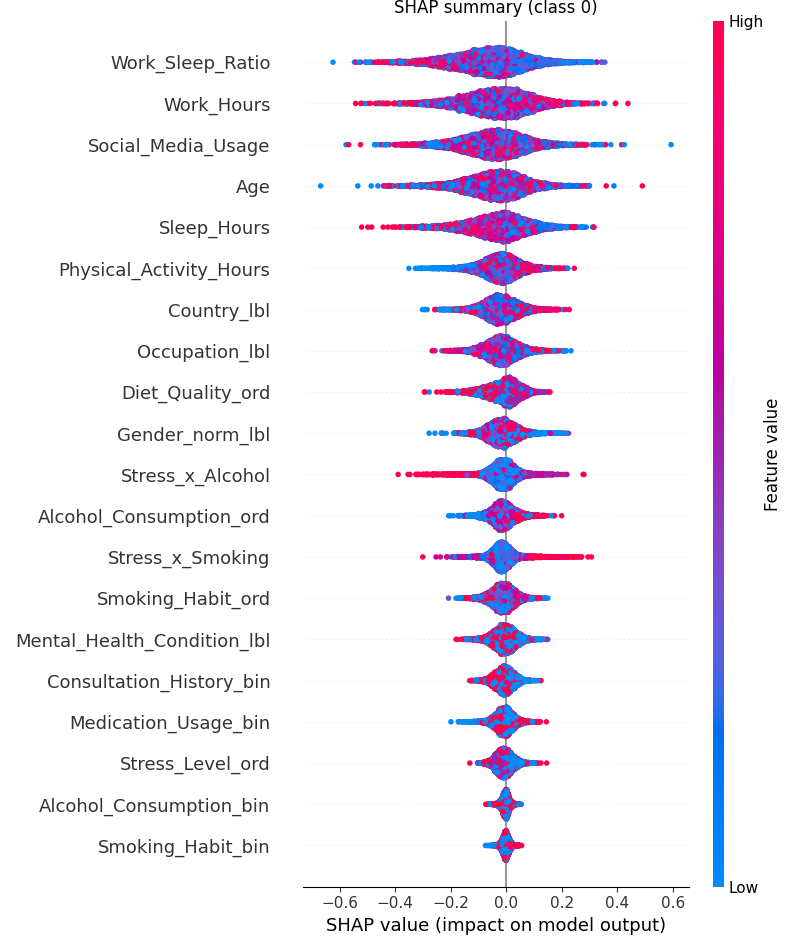


✅ Chunk 5 Complete: XGBoost SHAP analysis finished.


In [8]:
# Chunk 5: Explain the XGBoost Model with SHAP

print("--- Starting SHAP analysis for XGBoost model ---")
print("This helps explain which features the model found most important.")

# Use the 'final_model' from the previous cell, which is now an XGBoost model.
# --- UPDATE ---
# Point to the correct output directory for XGBoost.
out_dir = Path("/content/drive/MyDrive/MachineLearning/outputs_xgboost_v2")
feats = [c for c in X_train.columns if c != "row_id"]

# The compute_and_save_shap function is already designed to work with the XGBoost model
compute_and_save_shap(final_model, X_test[feats], feature_names=feats, out_dir=out_dir / "shap")

print("\n✅ Chunk 5 Complete: XGBoost SHAP analysis finished.")

In [9]:
# Chunk 6: Run Post-Hoc Threshold Evaluation for XGBoost

print("--- Starting Post-Hoc Threshold Evaluation for XGBoost ---")
print("This step loads the saved XGBoost model and tries to find better decision thresholds.")

def run_threshold_evaluation(data_path: Path):
    # --- UPDATE ---
    # Point to the saved XGBoost model and output directory
    MODEL_PATH = Path("/content/drive/MyDrive/MachineLearning/outputs_xgboost_v2/xgb_final.pkl")
    THR_DIR = Path("/content/drive/MyDrive/MachineLearning/outputs_xgboost_v2/thresholded")

    if not MODEL_PATH.exis     logger.error(f"Model not found at {MODEL_PATH}. Cannot run evaluation. Make sure Chunk 4 ran successfully.")
        return

    model = joblib.load(MODEL_PATH)
    # The X_val, y_val etc variables should still be in memory from Chunk 3

    feats = [c for c in X_val.columns if c != "row_id"]

    def find_class_thresholds(probs_val, y_val):
        print("Searching for best thresholds on the validation set...")
        thresholds = {}
        for c in range(probs_val.shape[1]):
            y_bin = (y_val == c).astype(int)
            best_t, best_f1 = 0.5, -1.0
            for t in np.linspace(0.2, 0.8, 31):
                f1 = f1_score(y_bin, (probs_val[:, c] >= t).astype(int), zero_division=0)
                if f1 > best_f1: best_f1, best_t = f1, t
            thresholds[c] = float(best_t)
        return thresholds

    def argmax_with_thresholds(probs, thresholds):
        t = np.array([thresholds[i] for i in sorted(thresholds.keys())])
        adjusted_probs = probs / t
        return adjusted_probs.argmax(axis=1)

    probs_val = model.predict_proba(X_val[feats])
    thresholds = find_class_thresholds(probs_val, y_val.values)
    probs_test = model.predict_proba(X_test[feats])
    preds_thr = argmax_with_thresholds(probs_test, thresholds)

    macro_f1 = f1_score(y_test, preds_thr, average="macro")

    print("\n--- XGBoost Threshold Evaluation Results ---")
    print(f"Final Macro F1-score with new thresholds: {macro_f1:.4f}")
    print(f"Optimal Class Thresholds Found: {thresholds}")
    report_thr = classification_report(y_test, preds_thr, target_names=["low", "med", "high"])
    print("\nClassification Report with new thresholds:")
    print(report_thr)
    THR_DIR.mkdir(parents=True, exist_ok=True)
    with open(THR_DIR / "classification_report_thresholded.txt", "w") as fh:
        fh.write(report_thr)
    print(f"\nThresholded report saved to {THR_DIR}")


run_threshold_evaluation(DRIVE_DATA_PATH)
print("\n✅ Chunk 6 Complete: XGBoost threshold evaluation finished.")

--- Starting Post-Hoc Threshold Evaluation for XGBoost ---
This step loads the saved XGBoost model and tries to find better decision thresholds.
Searching for best thresholds on the validation set...

--- XGBoost Threshold Evaluation Results ---
Final Macro F1-score with new thresholds: 0.3285
Optimal Class Thresholds Found: {0: 0.2, 1: 0.2, 2: 0.2}

Classification Report with new thresholds:
              precision    recall  f1-score   support

         low       0.16      0.17      0.16      1231
         med       0.67      0.65      0.66      5027
        high       0.16      0.17      0.16      1244

    accuracy                           0.49      7502
   macro avg       0.33      0.33      0.33      7502
weighted avg       0.50      0.49      0.49      7502


Thresholded report saved to /content/drive/MyDrive/MachineLearning/outputs_xgboost_v2/thresholded

✅ Chunk 6 Complete: XGBoost threshold evaluation finished.


In [12]:
# Chunk 8: Train and Evaluate a Final Model with SMOTE

# --- Step 1: Install the imbalanced-learn library ---
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from collections import Counter

print("--- Starting a new pipeline with SMOTE ---")

# --- Step 2: Load the data ---
print("Loading engineered data...")
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_data(DRIVE_DATA_PATH)

try:
    print(f"Using best XGBoost parameters: {best_params}")
except NameError:
    print("ERROR: 'best_params' not found. Please re-run Chunk 3 for XGBoost first.")
    best_params = {'max_depth': 8, 'learning_rate': 0.025, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.9, 'n_estimators': 400}


# --- Step 3: Apply SMOTE to the training data ---
print(f"\nOriginal training set shape: {Counter(y_train)}")
# FIX: Removed the n_jobs parameter, as it is not supported by SMOTE
smote = SMOTE(random_state=RND)
# IMPORTANT: Only apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Resampled training set shape (with SMOTE): {Counter(y_train_smote)}")


# --- Step 4: Train the final model on the SMOTE data ---
print("\nTraining final XGBoost model on SMOTE-balanced data...")
final_model_smote = train_final_xgb(
    X_train_smote, y_train_smote,
    X_val, y_val,
    best_params,
    sample_weight=None
)

# --- Step 5: Evaluate the model ---
print("\n--- Evaluating the SMOTE-trained model on the original test set ---")
out_dir = Path("/content/drive/MyDrive/MachineLearning/outputs_xgboost_v2_smote")
evaluate(final_model_smote, X_test, y_test, out_dir)

print("\n✅ New SMOTE pipeline complete.")

--- Starting a new pipeline with SMOTE ---
Loading engineered data...
Using best XGBoost parameters: {'max_depth': 8, 'learning_rate': 0.12367040189667017, 'subsample': 0.7604045832020067, 'colsample_bytree': 0.668147523279367, 'gamma': 0.5638898557686145, 'n_estimators': 668}

Original training set shape: Counter({1: 23417, 2: 5795, 0: 5787})
Resampled training set shape (with SMOTE): Counter({1: 23417, 0: 23417, 2: 23417})

Training final XGBoost model on SMOTE-balanced data...

--- Evaluating the SMOTE-trained model on the original test set ---

--- Main Model Classification Report ---
This report shows the performance of the fully-tuned model on the unseen test data.
              precision    recall  f1-score   support

         low       0.10      0.01      0.02      1231
         med       0.67      0.97      0.79      5027
        high       0.18      0.02      0.03      1244

    accuracy                           0.65      7502
   macro avg       0.32      0.33      0.28     